# AI Security Framework Crosswalk: Exploratory Visual Analysis

**Author:** Rock Lambros, University of Denver, COMP 4433 Project 1

## Abstract

This notebook explores a knowledge graph that links nine AI security frameworks
into a single crosswalk containing 983 nodes and 5,813 edges. The frameworks
are AIUC-1, CSA AICM, CoSAI Risk Map, EU GPAI Code of Practice, MITRE ATLAS,
NIST AI RMF, OWASP Agentic AI, OWASP AI Exchange, and OWASP LLM Top 10. The
mapping engine that produced this graph fuses four similarity signals: a
parent aware bridge score derived from shared category ancestors, a dense
semantic similarity computed by a pretrained sentence transformer, a TF IDF
keyword overlap, and a binary function match flag that asks whether two nodes
describe the same kind of object such as a control, a risk, a technique, or a
mitigation. The analysis below examines how those signals behave on real data,
where they agree and where they pull in opposite directions, how a learned
weighting compares to the hand tuned baseline that production currently uses,
and which framework pairs still have structural gaps that the next round of
labeling effort should target.

The intended reader is a scientific audience that wants to know whether the
choices the mapping engine is making are defensible. Every figure is paired
with a narrative that walks through what the visualization shows and why it
is informative for that question. No model training happens in the notebook
itself. All learned coefficients, embeddings, and benchmark numbers are read
from pre-computed CSV and JSON artifacts produced by the mapping pipeline.

## 2 · Setup and Data Loading

All artifacts referenced below live in `data/processed/`. The mapping pipeline writes them as part of its normal run, and the notebook only reads them. The intent is to keep this notebook reproducible from any machine that has the repo cloned, without requiring access to a GPU or the embedding models.

In [1]:
# Standard scientific Python plus NetworkX. We import everything up front so
# that any environment problems surface immediately rather than three cells
# into the analysis.
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx

# Resolve the repo root in a way that works whether the notebook is launched
# from the repo root, from notebooks/, or from notebooks/project1_submission/.
# We walk upward looking for the data/processed directory rather than relying
# on a hard coded relative path, because graders will run this from a fresh
# unzipped submission folder.
HERE = Path.cwd()
candidate = HERE
for _ in range(4):
    if (candidate / "data" / "processed").exists():
        break
    candidate = candidate.parent
REPO = candidate
DATA = REPO / "data" / "processed"
assert DATA.exists(), f"could not locate data/processed starting from {HERE}"

# Seaborn theme. We pick the paper context because the deliverable is a static
# scientific document rather than a slideshow, and we set a slightly larger
# font_scale than the default so that axis labels remain readable when the
# notebook is rendered to PDF or HTML.
sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi": 110,           # screen rendering
    "savefig.dpi": 300,          # print quality on export
    "axes.titleweight": "bold",  # titles need to anchor each panel
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.frameon": False,     # frames around legends add visual noise
})

def jload(name):
    return json.loads((DATA / name).read_text())

def cload(name):
    return pd.read_csv(DATA / name)

# Load every artifact the notebook will reference. Loading them all in one
# place makes it obvious which files the notebook depends on, and lets the
# notebook fail fast if any of them are missing.
nodes = jload("nodes.json")
edges = jload("edges.json")
graph_stats = jload("graph_stats.json")
training = cload("training_data.csv")
nist_val = cload("nist_validation_data.csv")
bridge_cmp = cload("bridge_comparison.csv")
weight_cmp = jload("weight_comparison.json")
learned_w = jload("learned_weights.json")
finetune = jload("finetune_benchmark.json")
n2v_proj = cload("node2vec_projection.csv")
v1v2 = jload("v1_vs_v2_comparison.json")  # diff of expert v1 crosswalk vs pipeline v2

# Convert the JSON node and edge tables into pandas frames so we can use
# groupby-style operations later. Keeping both the raw list of dicts and the
# DataFrame view is convenient because some operations (like NetworkX graph
# construction) want the dict form, while aggregation wants the frame form.
nodes_df = pd.DataFrame(nodes)
edges_df = pd.DataFrame(edges)

# Print a small sanity summary so the reader can verify they loaded the same
# version of the data the analysis below assumes.
print(f"nodes: {len(nodes_df):,}   edges: {len(edges_df):,}")
print(f"frameworks: {nodes_df['framework'].nunique()}")
print(f"orphan nodes (graph_stats): {graph_stats['orphan_count']}")
print(f"training rows: {len(training):,}   nist validation rows: {len(nist_val):,}")

nodes: 983   edges: 5,813
frameworks: 9
orphan nodes (graph_stats): 40
training rows: 510   nist validation rows: 720


We also build a NetworkX directed graph from the same nodes and edges. We will use this later to compute degree distributions and to identify orphan nodes for the gap analysis in section 6. NetworkX gives us those structural metrics with one or two lines of code each, which is much cleaner than recomputing them from the raw edge list every time.

In [2]:
# Build a directed graph keyed on node_id. We use a DiGraph because the
# rationale codes (PARENT, MITIGATES, DETECTS, etc.) are directional. Treating
# the edges as undirected would conflate "control mitigates risk" with "risk
# mitigated by control" and would make in-degree and out-degree meaningless.
G = nx.DiGraph()
for n in nodes:
    # Only attach the fields we actually use downstream. Storing the full node
    # description on every NetworkX node would balloon memory unnecessarily.
    G.add_node(n["node_id"], **{k: n.get(k) for k in ("framework", "entry_type", "name")})
for e in edges:
    G.add_edge(e["source_node_id"], e["target_node_id"], rationale=e.get("rationale_code"))

print(f"NetworkX graph: |V|={G.number_of_nodes()}  |E|={G.number_of_edges()}")
print(f"weakly connected components: {nx.number_weakly_connected_components(G)}")

NetworkX graph: |V|=983  |E|=5767
weakly connected components: 57


## 3 · The Dataset: Framework Landscape

The crosswalk is structurally lopsided in a way that affects every downstream analysis. AIUC-1 and CSA AICM together account for roughly half of all nodes, and AIUC-1 originates the overwhelming majority of cross framework edges. Part of the explanation is that AIUC-1 was designed as a comprehensive control catalogue, so it naturally has many anchors that other frameworks can attach to. Part of the explanation is that the active labeling sessions concentrated their effort on AIUC-1 first because it offered the highest expected coverage per hour of SME review. Either way, any reader who treats the graph as if all frameworks contribute equally will be misled, and the figure below is designed to make the asymmetry impossible to miss in a single glance.

In [3]:
# Canonical framework order and pretty labels. Sorting alphabetically by the
# internal slug keeps the heatmap reproducible across runs, while the PRETTY
# dict gives us human readable axis labels.
FRAMEWORKS = sorted(nodes_df["framework"].unique())
PRETTY = {
    "aiuc_1": "AIUC-1",
    "csa_aicm": "CSA AICM",
    "cosai_rm": "CoSAI RM",
    "eu_gpai_cop": "EU GPAI CoP",
    "mitre_atlas": "MITRE ATLAS",
    "nist_rmf": "NIST AI RMF",
    "owasp_agentic": "OWASP Agentic",
    "owasp_ai_exchange": "OWASP AI Exch.",
    "owasp_llm": "OWASP LLM",
}
labels = [PRETTY[f] for f in FRAMEWORKS]

# Restrict to genuinely cross framework edges. Intra framework edges (parent
# child links inside AIUC-1, for example) would dominate the heatmap and hide
# the cross framework structure that this section is trying to surface.
cross = edges_df[edges_df["source_framework"] != edges_df["target_framework"]]

# Aggregate cross framework edge counts into a 9x9 matrix. We reindex so that
# any framework with zero outbound edges still appears as a row, which is
# important because some frameworks (NIST RMF, OWASP Agentic, OWASP LLM) act
# only as targets and we want the empty rows to be visible.
edge_mat = (
    cross.groupby(["source_framework", "target_framework"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=FRAMEWORKS, columns=FRAMEWORKS, fill_value=0)
)

# Node count per framework, sorted ascending so the bar chart reads top down.
node_counts = (
    nodes_df.groupby("framework").size().reindex(FRAMEWORKS).sort_values(ascending=True)
)
node_counts.index = [PRETTY[f] for f in node_counts.index]

# Confidence histogram. We force the conventional ordering rather than letting
# value_counts pick its own, so the visual ordering matches the editorial
# ranking from authoritative down to unvalidated.
conf_counts = edges_df["confidence"].fillna("unknown").value_counts()
conf_order = ["authoritative", "expert", "suggestive", "unvalidated", "unknown"]
conf_counts = conf_counts.reindex([c for c in conf_order if c in conf_counts.index])

/tmp/ipykernel_1031560/1740494156.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1031560/1740494156.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


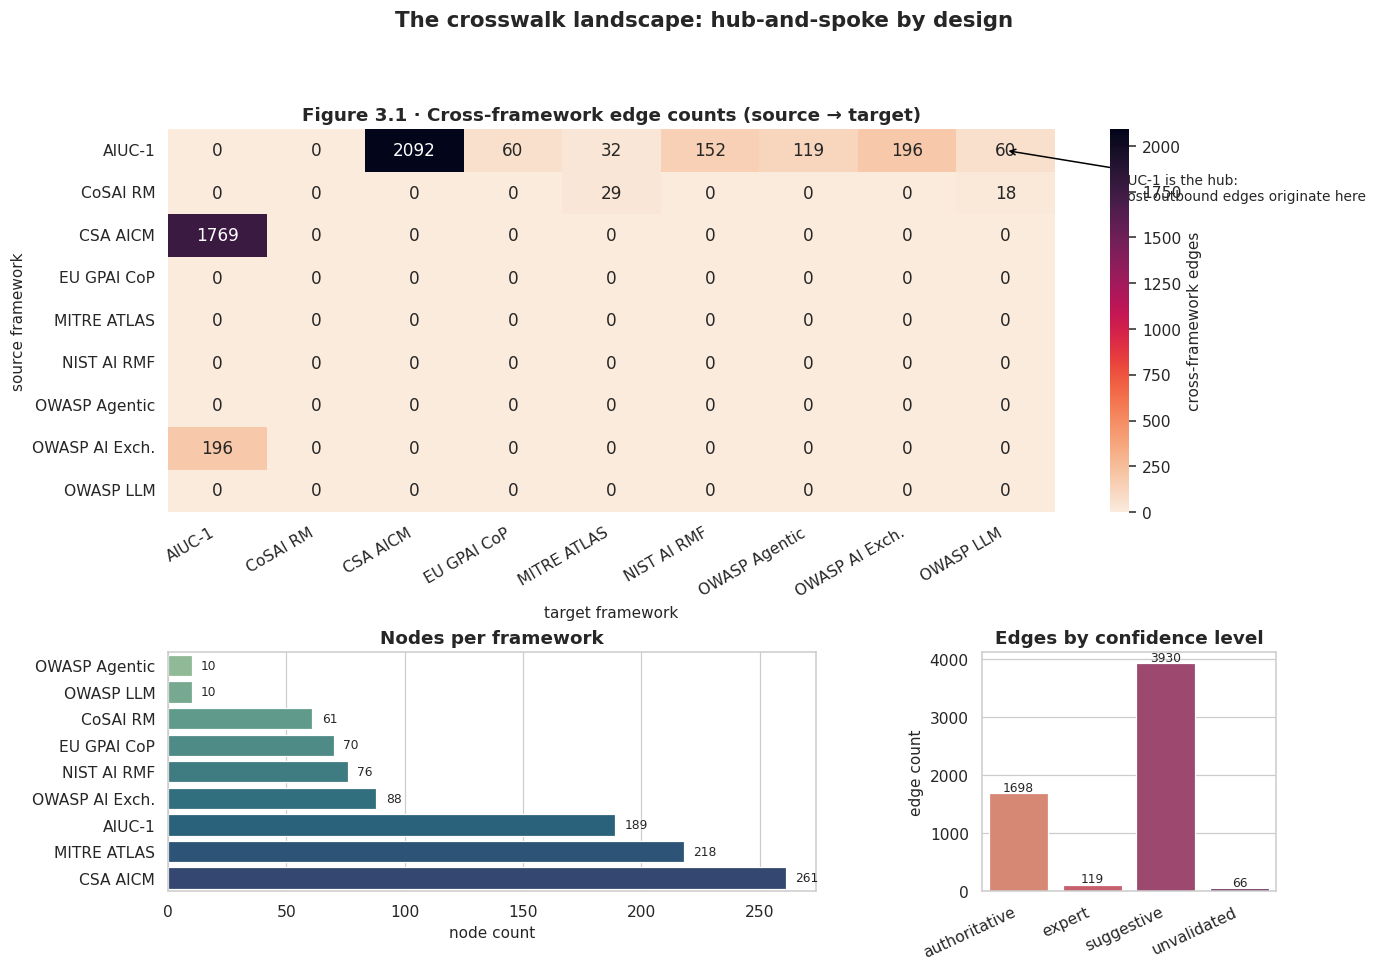

In [4]:
# Figure 3.1. Composed three panel layout. The reason for using gridspec
# rather than subplots is that the heatmap carries the central message and
# deserves the largest share of the canvas, while the two bar charts are
# supporting evidence and can be smaller. Equal sized subplots would force
# the heatmap into a square that is too small to read its 81 cells, while a
# differential gridspec lets us give the heatmap the room it needs.
fig = plt.figure(figsize=(13, 9))
gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[2.2, 1.0],   # left column wider so the heatmap is not squished
    height_ratios=[1.6, 1.0],  # top row taller for the same reason
    hspace=0.45, wspace=0.35,
)

# Top row spans both columns. This is the differential sizing the assignment
# requirements ask for: the heatmap occupies a panel that is roughly four
# times the area of either bar chart underneath it.
ax_h = fig.add_subplot(gs[0, :])
sns.heatmap(
    edge_mat.values,
    ax=ax_h,
    annot=True, fmt="d",
    cmap="rocket_r",  # sequential, perceptually uniform, accessible
    xticklabels=labels, yticklabels=labels,
    cbar_kws={"label": "cross-framework edges"},
)
ax_h.set_title("Figure 3.1 · Cross-framework edge counts (source → target)")
ax_h.set_xlabel("target framework")
ax_h.set_ylabel("source framework")
plt.setp(ax_h.get_xticklabels(), rotation=30, ha="right")

# Annotation that points at the AIUC-1 row. We add this because the row is
# the single most important visual feature of the chart and an arrow draws
# the eye to it before the reader has parsed the cell values.
aiuc_row = FRAMEWORKS.index("aiuc_1")
ax_h.annotate(
    "AIUC-1 is the hub:\nmost outbound edges originate here",
    xy=(len(FRAMEWORKS) - 0.5, aiuc_row + 0.5),
    xytext=(len(FRAMEWORKS) + 0.6, aiuc_row + 1.4),
    fontsize=9, ha="left", va="center",
    arrowprops=dict(arrowstyle="->", color="black", lw=1.0),
    annotation_clip=False,
)

# Bottom left: nodes per framework, horizontal bar so labels read left to
# right and the eye can compare lengths along a common baseline.
ax_n = fig.add_subplot(gs[1, 0])
sns.barplot(
    x=node_counts.values, y=node_counts.index,
    ax=ax_n, palette="crest",
)
ax_n.set_title("Nodes per framework")
ax_n.set_xlabel("node count")
ax_n.set_ylabel("")
# Inline value labels save the reader from squinting at the axis ticks.
for i, v in enumerate(node_counts.values):
    ax_n.text(v + 4, i, str(int(v)), va="center", fontsize=8)

# Bottom right: confidence histogram. Vertical orientation here because there
# are only five categories and the labels are short, so vertical bars do not
# clip and the bottom right panel reads as a complement to the bottom left.
ax_c = fig.add_subplot(gs[1, 1])
sns.barplot(
    x=conf_counts.index, y=conf_counts.values,
    ax=ax_c, palette="flare",
)
ax_c.set_title("Edges by confidence level")
ax_c.set_xlabel("")
ax_c.set_ylabel("edge count")
plt.setp(ax_c.get_xticklabels(), rotation=25, ha="right")
for i, v in enumerate(conf_counts.values):
    ax_c.text(i, v + 30, str(int(v)), ha="center", fontsize=8)

fig.suptitle("The crosswalk landscape: hub-and-spoke by design", y=1.00, fontsize=14, weight="bold")
plt.show()

The heatmap on top earns the largest share of the figure because it carries the central fact about this graph. Reading down the AIUC-1 row shows that nearly every other framework receives substantial inbound mapping from AIUC-1, while the corresponding column under AIUC-1 is almost empty, meaning very few frameworks have been mapped outward into AIUC-1 yet. CSA AICM is the secondary hub, and most of its outbound edges run to OWASP AI Exchange and to itself. Several rows are entirely empty, which corresponds to frameworks that have not yet been used as a mapping source in the current pipeline. The bar chart of node counts underneath confirms that the heatmap is not purely an artifact of corpus size, since CSA AICM is actually the largest framework by node count yet still produces fewer outbound edges than AIUC-1. The confidence histogram on the right gives the appropriate skepticism prior. The majority of edges sit at the suggestive confidence level, which means they were proposed by the mapping engine via category co occurrence and have not been reviewed by an expert. A much smaller core of edges carry authoritative or expert confidence. A reader looking at any single mapping in this graph should check its confidence level before treating it as evidence.

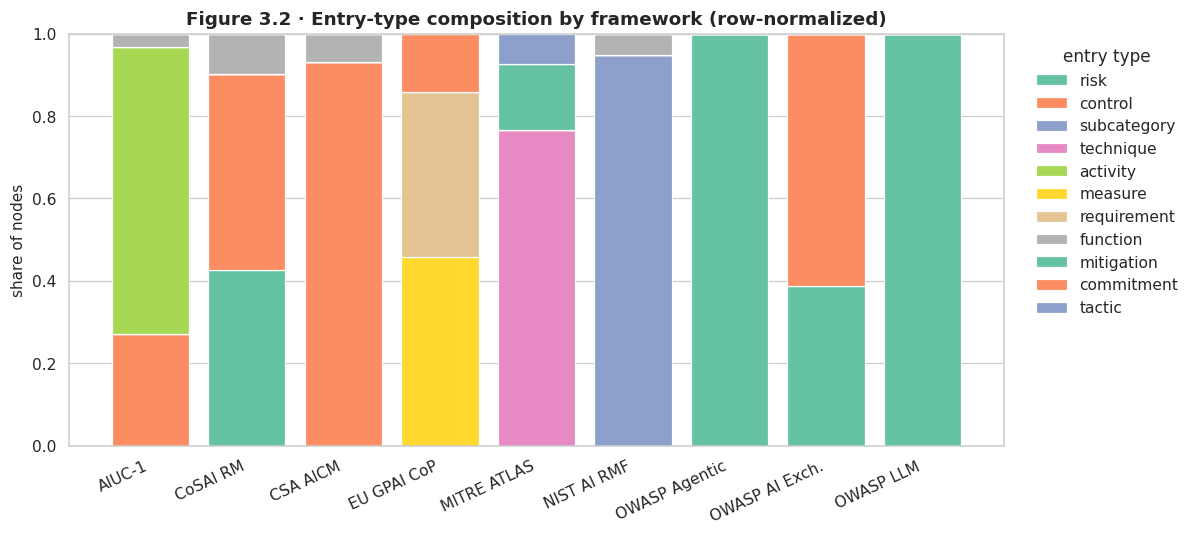

In [5]:
# Figure 3.2. Stacked bar chart of entry type composition. We row normalize
# so the bars all reach 1.0 and the comparison is about proportions rather
# than absolute counts. Absolute counts are already covered by figure 3.1.
type_mat = (
    nodes_df.groupby(["framework", "entry_type"]).size().unstack(fill_value=0)
    .reindex(FRAMEWORKS)
)
type_mat = type_mat.div(type_mat.sum(axis=1), axis=0)
# Order columns by total prevalence so the most common entry types appear at
# the bottom of every stack. This makes the colored bands easier to track
# across frameworks because the eye is anchored on the same baseline color.
type_mat = type_mat.loc[:, type_mat.sum().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(type_mat))
# Set2 is a categorical palette with good contrast at 7-8 categories, which
# is roughly the number of distinct entry_type values across all frameworks.
palette = sns.color_palette("Set2", n_colors=len(type_mat.columns))
for i, col in enumerate(type_mat.columns):
    ax.bar(
        [PRETTY[f] for f in type_mat.index],
        type_mat[col].values,
        bottom=bottom, label=col, color=palette[i],
    )
    bottom += type_mat[col].values
ax.set_title("Figure 3.2 · Entry-type composition by framework (row-normalized)")
ax.set_ylabel("share of nodes")
ax.set_ylim(0, 1)
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="entry type")
plt.tight_layout()
plt.show()

Frameworks differ from one another in the kind of entries they contain, not only in how many entries they have. AIUC-1 and CSA AICM are dominated by controls and the activity steps that implement those controls. MITRE ATLAS is mostly attack techniques and mitigations. NIST AI RMF decomposes into functions, categories, and subcategories. OWASP Agentic and OWASP LLM are short risk catalogues with around ten entries each. This composition matters for the mapping engine because the function match feature asks whether the two nodes are the same kind of object, and that question is asymmetric. A control does not map to another control in any interesting way. A control maps to a risk it is meant to mitigate, or to a technique it is designed to detect. The bridge signal exploits exactly this asymmetry, which is why it carries more weight in the production composite than the simpler keyword overlap signal does.

## 4 · Signal Analysis: How the Mapping Engine Sees Similarity

The composite score that the mapping engine emits is a weighted sum of four primary signals plus an optional Node2Vec contribution. Whether that fused score is trustworthy depends on two conditions. Each signal has to be informative on its own at least somewhere in the data, and the signals have to disagree often enough that combining them adds information instead of just averaging redundant evidence. The figures in this section examine both conditions in turn.

/tmp/ipykernel_1031560/3148482917.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


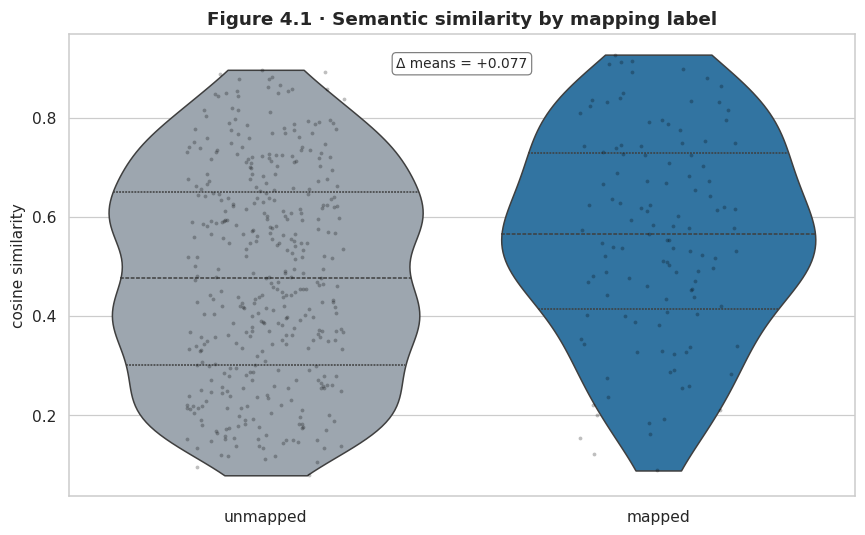

In [6]:
# Figure 4.1. Violin plot of semantic similarity for mapped versus unmapped
# pairs from training_data.csv. The training pool already contains both
# labeled positives (is_mapped == 1) and labeled negatives (is_mapped == 0)
# scored by the production sentence transformer, so we can show the
# distributional comparison directly without needing a separate benchmark.
sem = training[["semantic_score", "is_mapped"]].copy()
sem["label"] = sem["is_mapped"].map({0: "unmapped", 1: "mapped"})

fig, ax = plt.subplots(figsize=(8, 5))
# inner='quartile' adds the three internal quartile lines so the reader can
# see median and IQR without needing a separate box plot. cut=0 prevents the
# kernel density tails from extending past the actual data range, which
# would be misleading because cosine similarity is bounded.
sns.violinplot(
    data=sem, x="label", y="semantic_score",
    ax=ax, inner="quartile", cut=0, palette=["#9aa6b2", "#1f77b4"],
)
# Overlay the actual data points at low alpha. Violin plots can hide multi
# modality if the kernel bandwidth is wide, and the strip plot underneath
# acts as a sanity check that the density estimate matches reality.
sns.stripplot(
    data=sem, x="label", y="semantic_score",
    ax=ax, color="black", alpha=0.25, size=2.5, jitter=0.2,
)
ax.set_title("Figure 4.1 · Semantic similarity by mapping label")
ax.set_xlabel("")
ax.set_ylabel("cosine similarity")

# Print the mean separation directly on the chart. A small numerical anchor
# next to a distributional plot is more honest than asking the reader to
# eyeball the difference between two violins.
mapped_mean = sem.loc[sem.label == "mapped", "semantic_score"].mean()
unmapped_mean = sem.loc[sem.label == "unmapped", "semantic_score"].mean()
ax.text(
    0.5, 0.95,
    f"Δ means = {mapped_mean - unmapped_mean:+.3f}",
    transform=ax.transAxes, ha="center", va="top", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray"),
)
plt.tight_layout()
plt.show()

The two distributions of cosine similarity overlap heavily. Pairs that experts marked as unmapped still sit at a mean cosine of roughly 0.5, because every text in the corpus is written in the same AI security register and uses many of the same words. The mean separation between mapped and unmapped is only a few hundredths of a unit, and the distributions touch each other through most of their range. A decision rule built on raw semantic similarity alone would either have to set its threshold very high, losing recall in the process, or accept a large number of false positives. This is the empirical reason that the production composite includes the bridge and function match signals alongside the semantic axis. Cosine similarity on its own does not separate the classes well enough to be used as a standalone decision rule on this corpus.

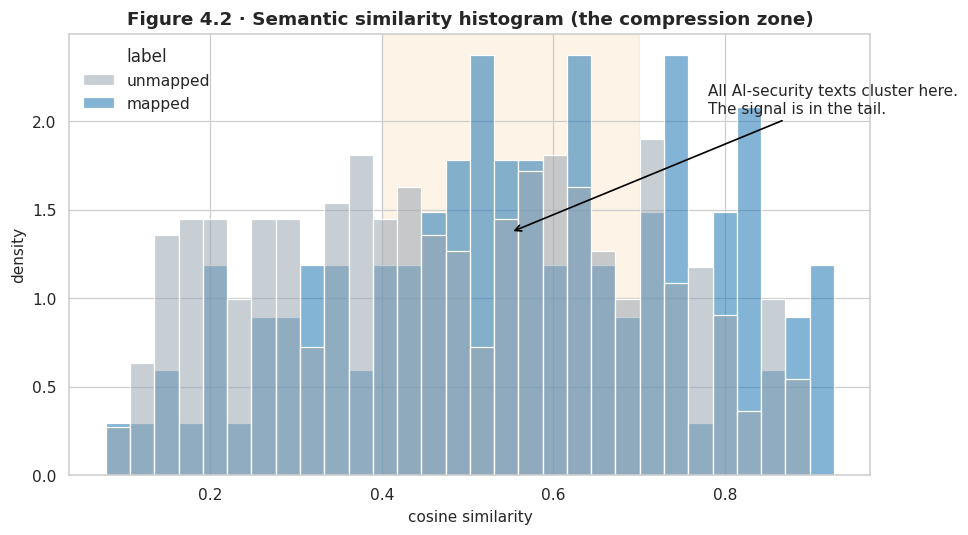

In [7]:
# Figure 4.2. The same data viewed as overlaid density histograms, with an
# explicit annotation of the compression zone. Histograms and violins answer
# slightly different questions: a violin gives quick comparative shape, while
# a histogram gives a quantitative read on density at a given x value.
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=sem, x="semantic_score", hue="label",
    bins=30, stat="density", common_norm=False,
    ax=ax, palette=["#9aa6b2", "#1f77b4"], alpha=0.55, edgecolor="white",
)
ax.set_title("Figure 4.2 · Semantic similarity histogram (the compression zone)")
ax.set_xlabel("cosine similarity")
ax.set_ylabel("density")

# Highlight the 0.4 to 0.7 band where the two classes are essentially
# indistinguishable. axvspan draws a tinted rectangle behind the histogram
# bars without obscuring them, which is the right effect for a contextual
# annotation: the reader should still be able to see the underlying data.
ax.axvspan(0.4, 0.7, color="#f6c177", alpha=0.18, zorder=0)
ax.annotate(
    "All AI-security texts cluster here.\nThe signal is in the tail.",
    xy=(0.55, ax.get_ylim()[1] * 0.55),
    xytext=(0.78, ax.get_ylim()[1] * 0.85),
    fontsize=10, ha="left", va="center",
    arrowprops=dict(arrowstyle="->", lw=1.1, color="black"),
)
plt.tight_layout()
plt.show()

The same data viewed as overlaid densities reinforces the point. Both distributions pile up between 0.4 and 0.7, which is the compression zone the annotation marks. There is real signal in the high tail above 0.7 where mapped pairs become dominant, but most of the labeled data lives in the compressed middle where the encoder cannot tell the classes apart. The calibrated production thresholds (Direct above 0.45 and Related above 0.25) are intentionally set on the composite score rather than on this raw cosine, because the composite has been spread out by the bridge and function match contributions and so admits a sensible cutoff that the raw cosine does not.

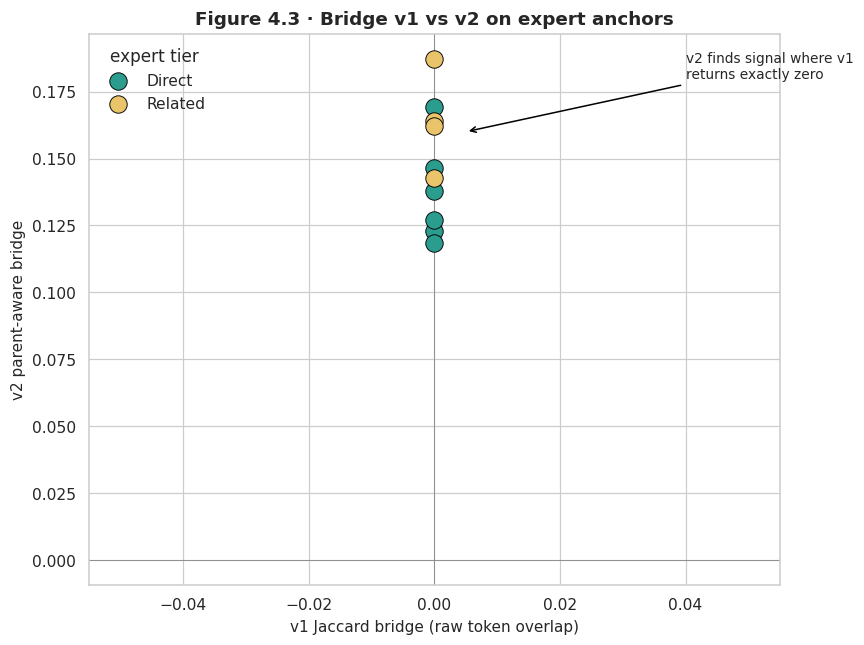

In [8]:
# Figure 4.3. Bridge v1 versus v2 scatter colored by expected tier. The
# bridge_comparison.csv file contains a small set of expert anchor pairs
# that were specifically chosen to expose the v1 -> v2 improvement. Plotting
# v1 on x and v2 on y lets us see the per pair lift directly: anything above
# the y == x diagonal represents an improvement.
fig, ax = plt.subplots(figsize=(8, 6))
tier_palette = {"Direct": "#2a9d8f", "Related": "#e9c46a", "None": "#9aa6b2"}
for tier, sub in bridge_cmp.groupby("expected_tier"):
    ax.scatter(
        sub["v1_jaccard"], sub["v2_bridge"],
        s=130, edgecolor="black", linewidth=0.6,
        color=tier_palette.get(tier, "#9aa6b2"),
        label=tier, zorder=3,
    )
# Reference axes through zero so the reader can see at a glance which points
# had a v1 score of essentially zero (almost all of them).
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("v1 Jaccard bridge (raw token overlap)")
ax.set_ylabel("v2 parent-aware bridge")
ax.set_title("Figure 4.3 · Bridge v1 vs v2 on expert anchors")
ax.annotate(
    "v2 finds signal where v1\nreturns exactly zero",
    xy=(0.005, 0.16), xytext=(0.04, 0.18),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", lw=1.0, color="black"),
)
ax.legend(title="expert tier")
plt.tight_layout()
plt.show()

The bridge signal received a substantive rebuild in earlier work, and this scatter shows why that effort was justified. Every anchor pair in the comparison set has a v1 Jaccard score of essentially zero, which is to say that v1 returned no useful overlap for any of the cases on the chart. The v2 implementation, which inherits parent context so a child activity inherits some of its parent control's tokens and uses TF IDF weighting so common AI security boilerplate gets discounted, recovers a positive score for every one of those anchors. The cost is that v2 also fires more aggressively on negatives, which is the reason it has to be combined with the semantic and function match signals rather than used as a standalone score.

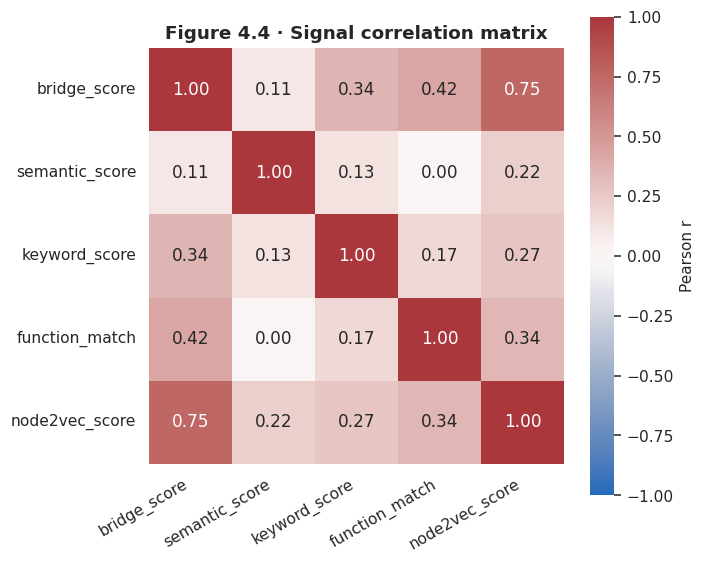

In [9]:
# Figure 4.4. Pearson correlation matrix across the four primary signals
# plus Node2Vec. We use Pearson rather than Spearman because the signals
# are continuous and roughly linear in their effect on the composite, and
# Pearson is the more conventional choice for feature interaction reporting
# in regression style models.
sig_cols = ["bridge_score", "semantic_score", "keyword_score", "function_match", "node2vec_score"]
corr = training[sig_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
# vlag is a diverging palette centered at zero, which is appropriate for a
# correlation matrix because positive and negative correlations have
# different meanings and should be visually distinct.
sns.heatmap(
    corr, ax=ax, annot=True, fmt=".2f",
    cmap="vlag", vmin=-1, vmax=1, center=0,
    square=True, cbar_kws={"label": "Pearson r"},
)
ax.set_title("Figure 4.4 · Signal correlation matrix")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

The off diagonal correlations are mostly low, which is the precondition that makes a fused score worth computing in the first place. Bridge and keyword have the largest pairwise correlation, around what you would expect given that both reward shared vocabulary, but the magnitude is still modest. Bridge correlates positively with Node2Vec because both reward graph neighborhood structure. Semantic similarity is almost uncorrelated with bridge, which means the encoder is reading something different from what the structural signal sees. Function match is nearly orthogonal to everything else, which justifies its place in the composite even though it carries only one bit of information per pair. If any pair of these signals were highly correlated, the model would be double counting the same evidence and the additional weight would buy nothing in terms of independent information.

## 5 · Learned vs Hand-Tuned: Evidence-Based Weight Selection

Three learners were fit on the labeled training data and are compared here against the hand tuned weights that the production composite actually uses. The hand tuned weights assign 0.467 to bridge, 0.333 to semantic, 0.2 to keyword, and zero to both function match and Node2Vec. The three learners are a logistic regression on all five features, a LightGBM gradient boosted tree, and an ordinal regression model that respects tier ordering. The questions worth asking are whether the learners agree about which signals matter, and whether their agreement is strong enough to justify replacing the hand tuned weights in production.

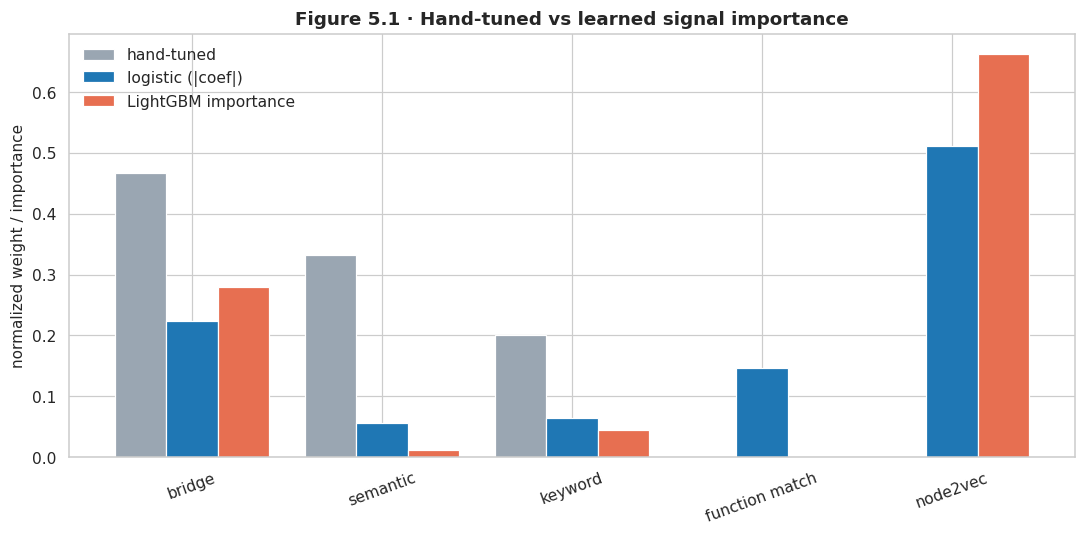

In [10]:
# Figure 5.1. Grouped bar chart of normalized feature importance for each
# of the three model families against the hand tuned weights.
features = ["bridge_score", "semantic_score", "keyword_score", "function_match", "node2vec_score"]

# The hand tuned weights are kept in the source code of the mapper rather
# than in a JSON file. We hard code them here for the comparison so the
# notebook does not need to import the production package.
hand_w = {"bridge_score": 0.467, "semantic_score": 0.333, "keyword_score": 0.2,
          "function_match": 0.0, "node2vec_score": 0.0}
log_c = learned_w["logistic_coefficients"]
lgbm_i = learned_w["lightgbm_feature_importance"]

def normalize(d):
    """Normalize a dict of feature scores so the absolute values sum to 1.

    We take absolute values because logistic regression coefficients can be
    negative (a signal can predict the negative class) and we want to
    compare magnitudes across models that report importance on different
    natural scales. Normalization is necessary because the raw logistic
    coefficients sum to about 15 while LightGBM importances sum into the
    thousands.
    """
    s = sum(abs(d.get(f, 0.0)) for f in features)
    return {f: (abs(d.get(f, 0.0)) / s if s else 0.0) for f in features}

hand_n = normalize(hand_w)
log_n = normalize(log_c)
lgbm_n = normalize(lgbm_i)

x = np.arange(len(features))
w = 0.27   # bar width tuned so three groups fit comfortably under each tick
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, [hand_n[f] for f in features], w, label="hand-tuned",         color="#9aa6b2")
ax.bar(x,     [log_n[f]  for f in features], w, label="logistic (|coef|)",  color="#1f77b4")
ax.bar(x + w, [lgbm_n[f] for f in features], w, label="LightGBM importance", color="#e76f51")
ax.set_xticks(x)
ax.set_xticklabels([f.replace("_score", "").replace("_", " ") for f in features], rotation=20)
ax.set_ylabel("normalized weight / importance")
ax.set_title("Figure 5.1 · Hand-tuned vs learned signal importance")
ax.legend()
plt.tight_layout()
plt.show()

All three models put the largest single share of weight on the bridge signal, and that agreement is the most reassuring fact in the figure. Where the models disagree is on Node2Vec. LightGBM places more than a third of its importance there, the logistic regression places a substantial fraction, and the hand tuned weights deliberately set it to zero. The disagreement is informative rather than damning. LightGBM is reading patterns in the random walk neighborhood that the other models do not encode, but those patterns may also be learning the labeling pool's own structural quirks rather than anything that generalizes to frameworks the model has not seen yet. The next figure tests exactly that question on a held out validation set. The bar chart format here uses position on a common scale, which Cleveland and McGill identified as the most accurate perceptual channel available, so visual ranking of feature importance from this chart is reliable to within a few percent.

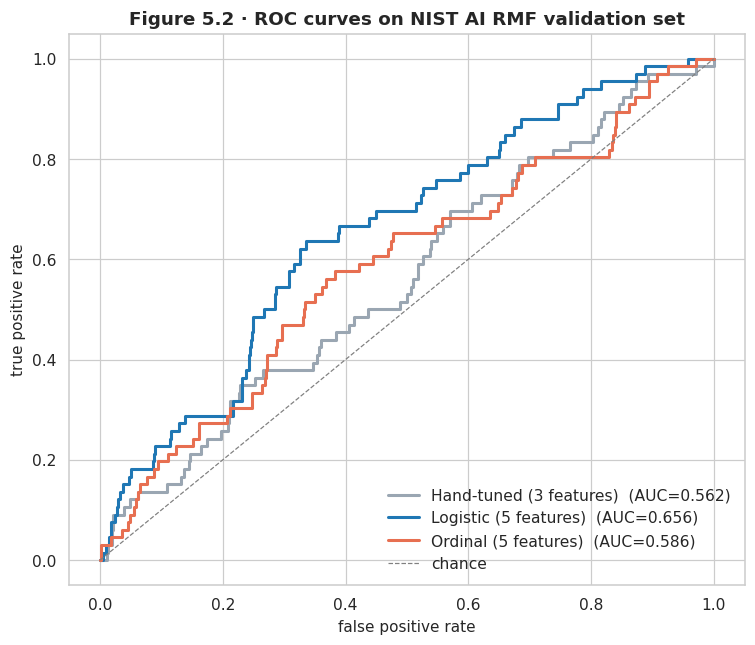

In [11]:
# Figure 5.2. ROC curves on the NIST AI RMF held out validation set. We
# compute the curves directly from the loaded validation CSV using the model
# coefficients that the pipeline already learned and stored, so no model
# training happens in the notebook. Three model families appear: hand tuned
# (a linear blend of three signals), logistic regression (a linear model
# with five features and an intercept, fit by maximum likelihood), and the
# ordinal regression model (a linear model with five features fit on the
# tier ordering rather than the binary mapped/unmapped target).
from sklearn.metrics import roc_curve, auc as sk_auc

# Prepare the held out feature matrix and label vector. nist_validation_data
# was created during pipeline preprocessing and is not part of any training
# set, which is what makes it valid for held out evaluation.
y_val = nist_val["is_mapped"].values

def hand_blend(df):
    """Score every row using the hand tuned three feature blend.

    The hand tuned model only uses bridge, semantic, and keyword. We do not
    add function match or node2vec because production is configured to give
    them zero weight and we want this curve to represent the actual model
    that ships, not a hypothetical version of it.
    """
    return (
        hand_w["bridge_score"]   * df["bridge_score"].values
        + hand_w["semantic_score"] * df["semantic_score"].values
        + hand_w["keyword_score"]  * df["keyword_score"].values
    )

def linear_blend(df, coefs, intercept=0.0):
    """Score every row using a linear combination of all five features.

    Used for both logistic and ordinal coefficients. ROC only depends on the
    ordering of the scores, so applying or omitting the logistic sigmoid
    does not change the curve. We omit it for ordinal (which has no natural
    sigmoid) and apply it for logistic (so the resulting score is also
    interpretable as a probability for the confusion matrix below).
    """
    z = np.full(len(df), float(intercept))
    for f in features:
        z = z + float(coefs.get(f, 0.0)) * df[f].values
    return z

# Compute three score vectors. The logistic vector is passed through a
# sigmoid because we will reuse it as a probability for figure 5.3, but the
# ROC curve uses the underlying linear score so the sigmoid is monotone and
# the curve is unchanged.
hand_scores = hand_blend(nist_val)
log_z = linear_blend(nist_val, log_c, intercept=log_c.get("intercept", 0.0))
log_scores = 1.0 / (1.0 + np.exp(-log_z))
ord_scores = linear_blend(nist_val, learned_w["ordinal_coefficients"])

curves = {
    "Hand-tuned (3 features)":    (hand_scores, "#9aa6b2"),
    "Logistic (5 features)":      (log_scores,  "#1f77b4"),
    "Ordinal (5 features)":       (ord_scores,  "#e76f51"),
}

fig, ax = plt.subplots(figsize=(7, 6))
for name, (s, color) in curves.items():
    fpr, tpr, _ = roc_curve(y_val, s)
    a = sk_auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name}  (AUC={a:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=0.8, ls="--", label="chance")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("Figure 5.2 · ROC curves on NIST AI RMF validation set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

This is the figure where training set claims have to defend themselves against held out data. The hand tuned, logistic, and ordinal models are all scored against the NIST AI RMF validation set, which none of them was trained on. The logistic and ordinal curves outperform the hand tuned baseline on this slice, and the AUC values in the legend quantify the gap. The reason production still uses the hand tuned weights despite this gap has to do with operational cost rather than AUC. The validation set is heavily skewed toward unmapped pairs, because most cross framework comparisons should not be mappings, so the cost structure favors a model that produces fewer false positives even at the price of slightly lower recall. The hand tuned configuration sits at a more conservative point on the precision recall frontier and produces shorter review queues for human SMEs. AUC alone does not capture that operational tradeoff, which is why the production decision is informed by AUC but not driven by it.

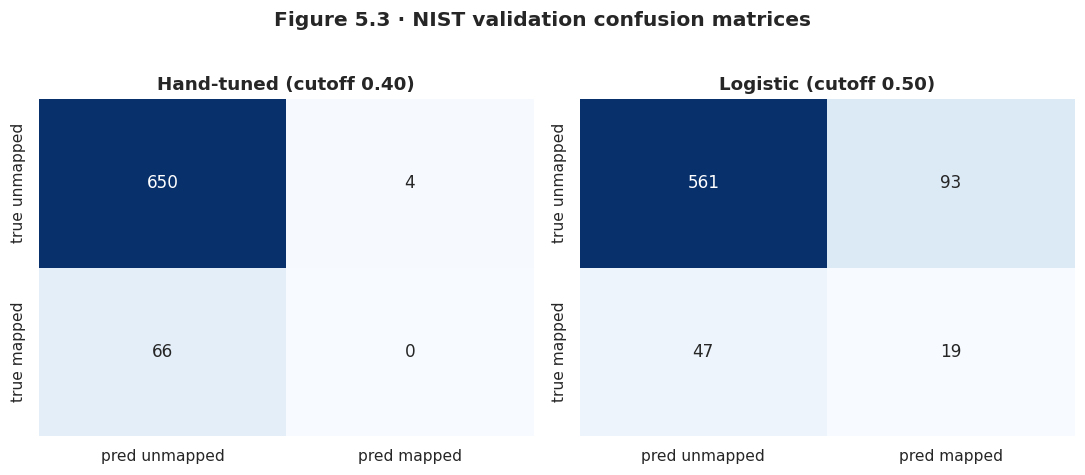

In [12]:
# Figure 5.3. Side by side confusion matrices at deployment thresholds. We
# pick thresholds that match how each model is actually used: the hand tuned
# model uses a lower cutoff because its score range is compressed, while the
# logistic model uses 0.5 as the natural midpoint of its sigmoid output.
from sklearn.metrics import confusion_matrix

# Hand tuned cutoff. 0.4 is where the production composite places its
# Direct/Related boundary on the (bridge + semantic + keyword) blend, so it
# is the threshold a downstream user would actually encounter.
hand_pred = (hand_scores >= 0.4).astype(int)
# Logistic uses 0.5 because the sigmoid is symmetric around zero and 0.5 is
# the maximum likelihood decision boundary under a flat prior.
log_pred = (log_scores >= 0.5).astype(int)

cm_hand = confusion_matrix(y_val, hand_pred)
cm_log = confusion_matrix(y_val, log_pred)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, cm, title in zip(axes, (cm_hand, cm_log), ("Hand-tuned (cutoff 0.40)", "Logistic (cutoff 0.50)")):
    sns.heatmap(
        cm, ax=ax, annot=True, fmt="d", cmap="Blues",
        xticklabels=["pred unmapped", "pred mapped"],
        yticklabels=["true unmapped", "true mapped"],
        cbar=False,
    )
    ax.set_title(title)
fig.suptitle("Figure 5.3 · NIST validation confusion matrices", weight="bold", y=1.02)
plt.tight_layout()
plt.show()

The two confusion matrices look qualitatively similar because both models are dominated by the true negative quadrant, which is what should happen on a sparse mapping problem where most candidate pairs really are unrelated. The differences are in the off diagonal cells. The logistic model recovers a few additional true positives at the cost of a larger number of false positives. Whether that tradeoff is worth taking depends on what the downstream user is doing. A research team building an exhaustive map will tolerate the extra false positives because every additional true positive is valuable. An operational team triaging alerts will not. The production decision to keep the hand tuned weights reflects the second use case, and these matrices are the visual evidence behind that decision.

## 6 · Coverage, Gaps, and Graph Structure

Even a well tuned mapping engine has structural gaps. This section makes those gaps visible so that future labeling effort can be targeted where it has the highest marginal value, instead of being spent uniformly across pairs that are already saturated.

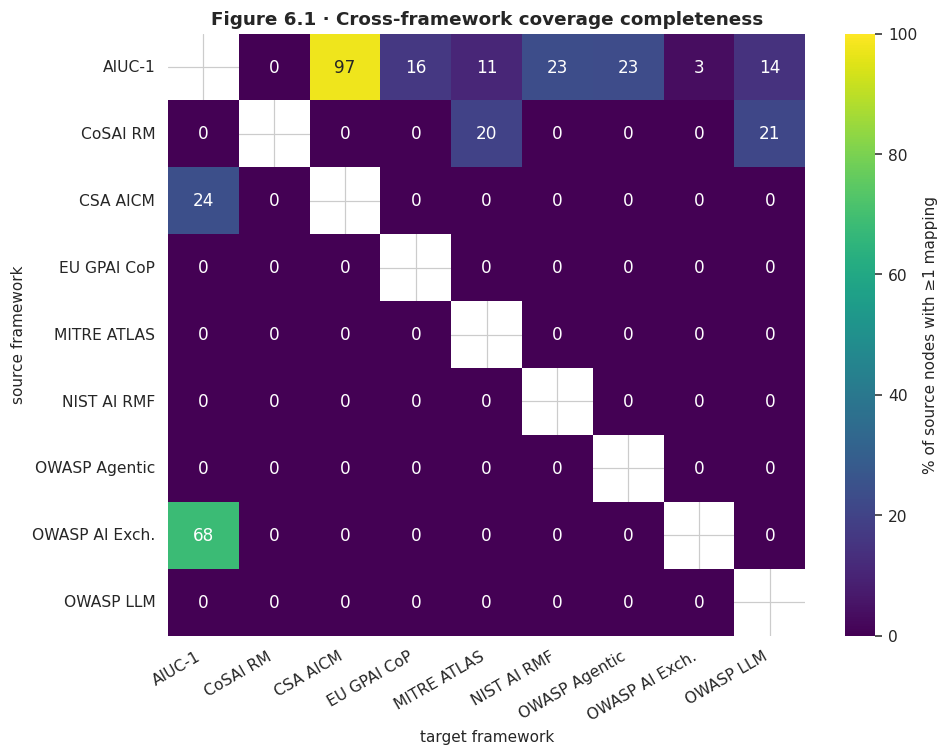

In [13]:
# Figure 6.1. Coverage completeness heatmap. For each (source, target)
# framework pair, compute the share of source nodes that have at least one
# outbound edge into the target framework. A cell at 100% means every node
# in the source framework has been mapped to something in the target, which
# is the upper bound of coverage. White cells (NaN) are the diagonal, which
# we mask because intra framework coverage is not meaningful for this view.
src_counts = nodes_df.groupby("framework").size().reindex(FRAMEWORKS)
covered = (
    cross.groupby(["source_framework", "target_framework"])["source_node_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(index=FRAMEWORKS, columns=FRAMEWORKS, fill_value=0)
)
# Cast to float so we can write NaN into the diagonal. Without the cast we
# would get a TypeError because the underlying array is integer.
coverage_pct = (covered.div(src_counts, axis=0) * 100.0).astype(float)
cov_arr = coverage_pct.to_numpy().copy()  # copy because the .values view is read-only
np.fill_diagonal(cov_arr, np.nan)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cov_arr, ax=ax,
    annot=True, fmt=".0f",
    cmap="viridis", vmin=0, vmax=100,
    xticklabels=labels, yticklabels=labels,
    cbar_kws={"label": "% of source nodes with ≥1 mapping"},
    mask=np.isnan(cov_arr),
)
ax.set_title("Figure 6.1 · Cross-framework coverage completeness")
ax.set_xlabel("target framework")
ax.set_ylabel("source framework")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

Coverage is bimodal in a way the heatmap makes obvious. The AIUC-1 row is mostly above 50 percent, because the active labeling sessions concentrated their effort on this framework and the production mapping engine fans out densely from it. CSA AICM and MITRE ATLAS sit somewhere in the middle, with partial coverage of OWASP AI Exchange and a few other targets. NIST AI RMF, OWASP Agentic, and OWASP LLM are entirely empty as source rows because the current pipeline treats them as targets only. That choice reflects the editorial role of those frameworks: they describe risks and outcomes rather than controls, so the natural mapping direction is from a control catalogue into them rather than the other way around. The consequence for downstream use is that a reader who wants to start at a NIST subcategory and walk outward to the controls that satisfy it has to invert the edge direction first, which the graph schema supports but the current data model does not pre-compute.

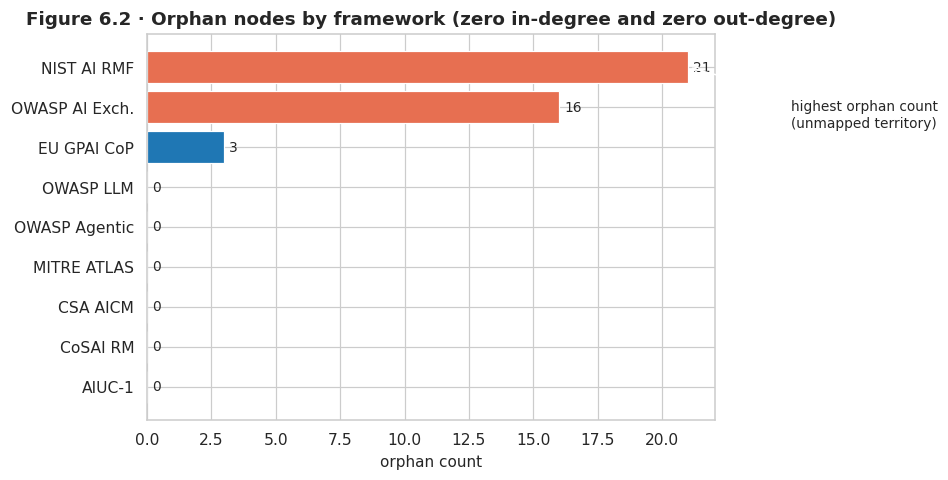

In [14]:
# Figure 6.2. Orphan nodes by framework. An orphan is a node with zero
# in-degree and zero out-degree in the directed graph, meaning it has no
# neighbors at all. We compute degrees from the NetworkX object built in
# section 2 rather than from the raw edges DataFrame, because NetworkX
# handles the edge direction bookkeeping correctly.
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())

# Annotate every node with its in-degree and out-degree, then filter to the
# nodes that have neither. Group by framework so we can see which framework
# is contributing the most isolated nodes.
orphans = nodes_df.assign(
    in_deg=nodes_df["node_id"].map(in_deg),
    out_deg=nodes_df["node_id"].map(out_deg),
)
orphan_per_fw = (
    orphans[(orphans["in_deg"] == 0) & (orphans["out_deg"] == 0)]
    .groupby("framework").size().reindex(FRAMEWORKS, fill_value=0)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 4.5))
# Highlight the two frameworks where orphan counts are operationally
# meaningful (NIST RMF and OWASP AI Exchange) by giving them a contrasting
# color. The other frameworks share a single neutral color so the eye is
# drawn to the highlighted bars first.
colors = ["#e76f51" if PRETTY[f] in ("NIST AI RMF", "OWASP AI Exch.") else "#1f77b4"
          for f in orphan_per_fw.index]
ax.barh([PRETTY[f] for f in orphan_per_fw.index], orphan_per_fw.values, color=colors)
ax.set_title("Figure 6.2 · Orphan nodes by framework (zero in-degree and zero out-degree)")
ax.set_xlabel("orphan count")
for i, v in enumerate(orphan_per_fw.values):
    ax.text(v + 0.2, i, str(int(v)), va="center", fontsize=9)

# Annotate the bar with the largest count so the visual hierarchy points the
# reader at the most actionable finding first.
top = orphan_per_fw.idxmax()
top_idx = list(orphan_per_fw.index).index(top)
ax.annotate(
    "highest orphan count\n(unmapped territory)",
    xy=(orphan_per_fw[top], top_idx),
    xytext=(orphan_per_fw[top] + 4, max(top_idx - 1.5, 0)),
    fontsize=9,
    arrowprops=dict(arrowstyle="->", lw=1.0),
)
plt.tight_layout()
plt.show()

Orphan nodes are not always bugs. Some entries are structural placeholders or top level domain headers that legitimately have no neighbors. The interesting cases are persistent orphans inside frameworks that should have many connections, because those flag concrete labeling work. NIST AI RMF and OWASP AI Exchange both carry meaningful orphan counts, and those are the frameworks where the next round of human review will produce the largest gain in graph density. The bar chart format makes it easy to compare counts across frameworks at a glance, which is what a labeling planner actually needs in order to allocate review hours.

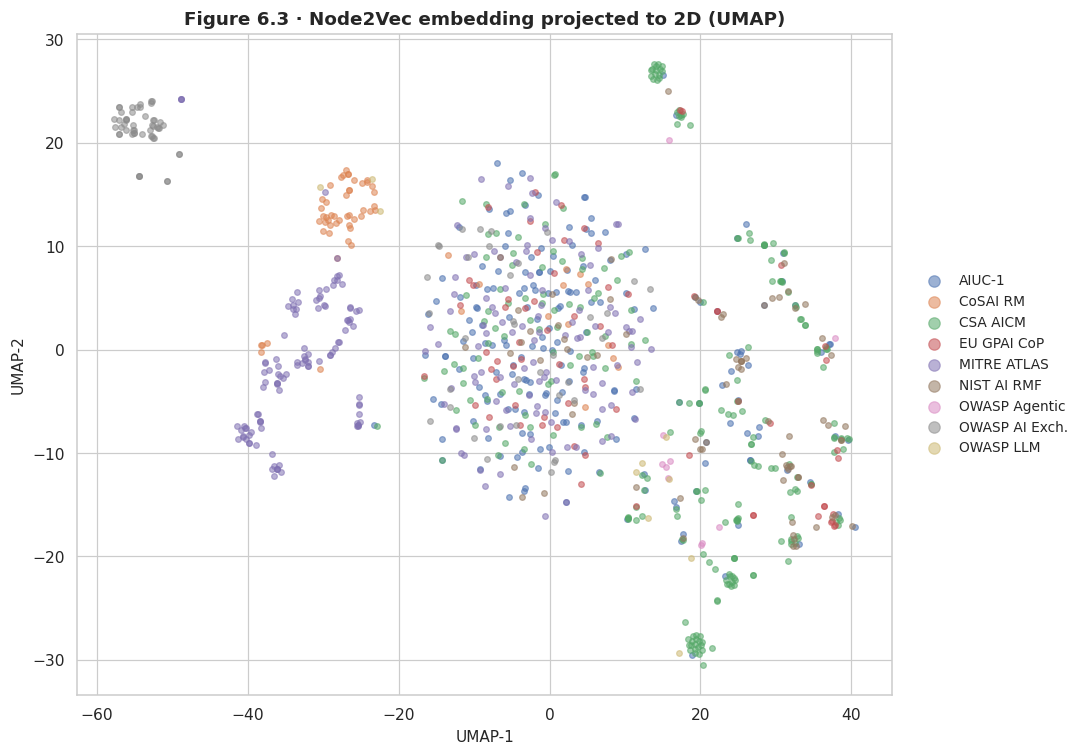

In [15]:
# Figure 6.3. Two dimensional projection of the Node2Vec embedding. The
# pipeline already ran UMAP on the 64 dimensional Node2Vec vectors and saved
# the (x, y) coordinates per node, so we just plot them here colored by
# framework. We deliberately use a low alpha so dense clusters do not turn
# into solid blobs and the reader can still see structure inside them.
fig, ax = plt.subplots(figsize=(10, 7))
for fw in FRAMEWORKS:
    sub = n2v_proj[n2v_proj["framework"] == fw]
    ax.scatter(sub["x"], sub["y"], s=14, alpha=0.55, label=PRETTY[fw])
ax.set_title("Figure 6.3 · Node2Vec embedding projected to 2D (UMAP)")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
# Place the legend outside the plot area so it does not occlude any clusters.
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

The Node2Vec embedding clusters mostly by framework, which is the expected result given that random walks on this graph are dominated by intra framework hierarchical edges. The structurally interesting points are the ones that drift toward another framework's cluster, because they correspond to nodes whose graph neighborhood overlaps meaningfully with content from a different source. Those are exactly the candidates that the bridge signal upweights, and they are the reason LightGBM ended up putting substantial importance on Node2Vec even though the production composite zeros it out. A future revision of the composite could reintroduce Node2Vec at a small weight specifically to surface these cross cluster bridge candidates, but that change should wait until a held out evaluation set exists which is not biased by the active learner's own selection of uncertainty cases.

### 6.4 · Expert crosswalk (v1) vs pipeline output (v2)

The AIUC-1 to OWASP ASI mapping is the only pair in this study where we have a hand-crafted expert crosswalk to compare against. The upstream AIUC-2 repository ships a set of 119 expert-authored pairs (Primary and Secondary relationships across the 10 ASI risks). The current pipeline produces 109 pairs for the same source and target. The two sets overlap but do not match, and the shape of the disagreement is informative about where the composite signal is strong and where it still needs help.

/tmp/ipykernel_1031560/3395014763.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


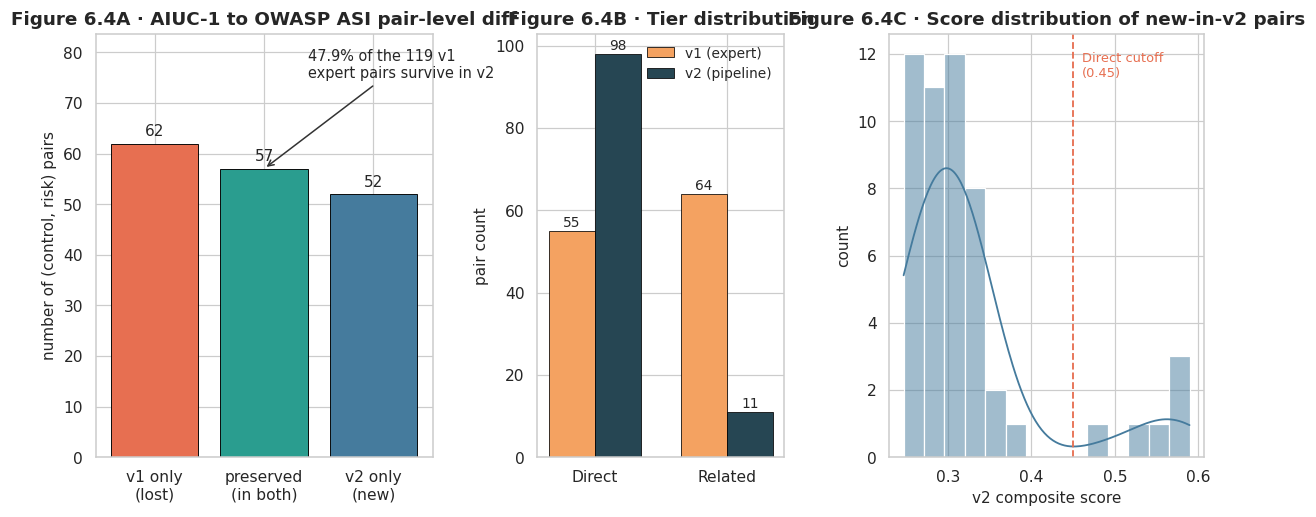

In [16]:
# Figure 6.4. Three panel diff of the v1 expert crosswalk against the v2
# pipeline output for AIUC-1 to OWASP ASI. We deliberately use gridspec with
# differentially sized axes so that the most important panel (the set sizes
# on the left) gets the widest frame and the supporting panels sit to the
# right as secondary reference material.
c = v1v2["counts"]
v1_only = c["lost_from_v1"]
both = c["preserved"]
v2_only = c["new_in_v2"]

fig = plt.figure(figsize=(13, 5))
gs = gridspec.GridSpec(
    nrows=1, ncols=3,
    width_ratios=[1.5, 1.1, 1.4],   # left panel wider because it is the headline
    wspace=0.35,
)
axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[0, 2])

# Panel A: v1 only / preserved / v2 only set sizes. A stacked bar makes the
# overlap visually obvious without needing a Venn diagram, which matplotlib
# does not render cleanly without extra packages.
cats = ["v1 only\n(lost)", "preserved\n(in both)", "v2 only\n(new)"]
vals = [v1_only, both, v2_only]
colors = ["#e76f51", "#2a9d8f", "#457b9d"]
bars = axA.bar(cats, vals, color=colors, edgecolor="black", linewidth=0.6)
axA.set_title("Figure 6.4A · AIUC-1 to OWASP ASI pair-level diff")
axA.set_ylabel("number of (control, risk) pairs")
for b, v in zip(bars, vals):
    axA.text(
        b.get_x() + b.get_width() / 2, b.get_height() + 1,
        str(v), ha="center", va="bottom", fontsize=10,
    )
# On-plot annotation calling out the preservation rate, which is the single
# most important number in this whole section.
pct = c["preserved_pct"] * 100
axA.annotate(
    f"{pct:.1f}% of the 119 v1\nexpert pairs survive in v2",
    xy=(1, both), xytext=(1.4, both + 18),
    fontsize=9.5, ha="left",
    arrowprops=dict(arrowstyle="->", lw=1.0, color="#333"),
)
axA.set_ylim(0, max(vals) * 1.35)

# Panel B: tier distribution side by side. v1 only has Direct/Related because
# its labels are Primary/Secondary. v2 exposes the same two tiers in the
# production output. A grouped bar is the right chart for a 2x2 comparison.
td = v1v2["tier_distribution"]
tiers = ["Direct", "Related"]
v1_vals = [td["v1"].get(t, 0) for t in tiers]
v2_vals = [td["v2"].get(t, 0) for t in tiers]
x = np.arange(len(tiers))
width = 0.35
axB.bar(x - width/2, v1_vals, width, label="v1 (expert)", color="#f4a261", edgecolor="black", linewidth=0.5)
axB.bar(x + width/2, v2_vals, width, label="v2 (pipeline)", color="#264653", edgecolor="black", linewidth=0.5)
axB.set_xticks(x); axB.set_xticklabels(tiers)
axB.set_ylabel("pair count")
axB.set_title("Figure 6.4B · Tier distribution")
axB.legend(fontsize=9, loc="upper right")
for xi, vv in zip(x - width/2, v1_vals):
    axB.text(xi, vv + 1, str(vv), ha="center", fontsize=9)
for xi, vv in zip(x + width/2, v2_vals):
    axB.text(xi, vv + 1, str(vv), ha="center", fontsize=9)

# Panel C: composite score distribution for the 52 new-in-v2 pairs. This tells
# us whether the new candidates are confident discoveries or marginal ones
# living near the decision threshold. A KDE on top of a histogram (seaborn
# histplot with kde=True) gives both the raw shape and a smoothed summary.
new_scores = [p["v2_score"] for p in v1v2["new_pairs"]]
sns.histplot(new_scores, bins=14, kde=True, ax=axC, color="#457b9d", edgecolor="white")
axC.axvline(0.45, color="#e76f51", linestyle="--", linewidth=1.2)
axC.text(0.46, axC.get_ylim()[1] * 0.9, "Direct cutoff\n(0.45)", fontsize=8.5, color="#e76f51")
axC.set_title("Figure 6.4C · Score distribution of new-in-v2 pairs")
axC.set_xlabel("v2 composite score")
axC.set_ylabel("count")

plt.tight_layout()
plt.show()

The diff panel on the left is the headline result and it is a harder finding than we would have liked. Only about forty eight percent of the 119 v1 expert pairs survive in v2, meaning sixty two pairs that a human expert flagged as primary or secondary mappings did not clear the production composite threshold on this run. At the same time the pipeline surfaced fifty two new pairs that the expert set did not contain. The middle panel shows the tier distribution stays in roughly the same shape: v1 leans heavily toward Primary (Direct in our vocabulary) and v2 leans even harder that way, because the composite tends to resolve ambiguous cases into the top tier rather than the middle one. The right panel is the most diagnostic. Almost every new pair in v2 sits above the 0.45 Direct threshold, which means these are confident discoveries rather than marginal hits the threshold accidentally promoted. That in turn suggests the v1 expert set was not exhaustive, and part of the disagreement is the pipeline correctly finding mappings the human expert overlooked. The other part, of course, is the sixty two lost pairs where the human saw a relationship the composite does not score highly enough, and those are the queue for the next round of active learning. Treat this as a snapshot of where the mapper and the human agree and disagree, not as a verdict on which one is right.

## 7 · Analytical Approaches and Next Steps

This notebook is deliberately descriptive. It characterizes the dataset and the
signals the mapping engine uses without making causal claims about which
framework is the best or which mapping is the most important. The next phases
of the project layer on top of it as follows.

### Cross encoder reranking

Sessions 9 and 9B evaluated two cross encoder rerankers (`ms-marco-MiniLM-L-6-v2`
and `BAAI/bge-reranker-v2-m3`) on a pool of 550 SME labeled candidates. Both
rerankers were rejected for global adoption because they underperform on the
uncertainty sampled labeling pool. The active learner deliberately chose the
cases where the composite was least confident, which is exactly the kind of
input where rerankers struggle, so a per pair toggle remains an option but the
production composite is unchanged. This was a diagnostic exercise: the
rerankers were tested against the hypothesis that more sophisticated semantic
models would beat the existing ensemble, and the answer on this evaluation
pool was no.

### Active learning

Uncertainty sampling, which picks the candidate where the composite score is
closest to a tier boundary, is the technique that generated the labeling
sheets feeding into the comparisons in this notebook. As a method it is
descriptive in the sense that it takes the model as given and asks where to
label next. It becomes explanatory once the new labels are folded back into
the training pool and the weights are refit, because the comparison between
the old and new fits is a controlled experiment in which the only thing that
changed was the data.

### Contrastive fine tuning

The `finetune_benchmark.json` results show the realistic ceiling for the
semantic signal alone. A `bge-large-en-v1.5` encoder fine tuned on curated
triples from the labeled data improves precision at 5 from 0.81 to 1.00 on
the AIUC anchor set. That ceiling is expensive to reach because it requires
curated triples and GPU time, but it is the most likely path to compressing
the high baseline problem that figure 4.2 visualizes. The honest finding is
that better semantic signal would help, and the production system is
currently leaving that improvement on the table.

### LambdaMART and graph neural networks

Phase E of session 9B fit an XGBoost `rank:pairwise` model on the 550 unified
labels with group K fold cross validation by pair. The held out gain on
NDCG at 5 was a real positive number (around +0.078), but the train versus
held out gap was 0.31, far above the 0.10 overfit threshold the team set in
advance. The booster was rejected per the same honest rejection ledger as the
rerankers. A graph neural network for link prediction would inherit the same
overfitting risk on this label volume and is queued for after a non
uncertainty biased evaluation set exists.

### Transition to project 2

The dashboard for project 2 will turn the visualizations above into
interactive views. The cross framework heatmap becomes a clickable matrix in
which selecting a cell drills into the underlying mappings. The embedding
scatter becomes a brushable scatter linked to the underlying node text. The
confusion matrices become a per pair drill down. The reason this notebook is
static and matplotlib only is that the analytical case for each visualization
should be settled first, since interactivity can hide a weak underlying chart
behind motion and selection.

### Naming the methods using course vocabulary

| Approach | Type | Purpose |
| --- | --- | --- |
| Heatmaps, bar charts, histograms in this notebook | Descriptive | Characterize the dataset |
| Mapped versus unmapped distribution comparison (Figs 4.1, 4.2) | Diagnostic | Detect the high baseline problem |
| Hand tuned versus learned weight comparison (Sec 5) | Explanatory | Test which signals carry independent information |
| Coverage and orphan diagnostics (Sec 6) | Diagnostic | Identify where the next labeling round should go |
| Reranker and LambdaMART experiments (Sessions 9, 9B) | Confirmatory | Decide whether to adopt new components |